 # **Proyecto Final - Etapa II - Machine Learning 🧠** | **Clasificación de ritmo cardiaco 🖤**
---

> Miguel Contardo Ramos - 18/06/2025

---

## **1. Limpieza de los datos**
- Antes de entrenar un modelo de ML, se debe realizar una limpieza de los datos existentes. En este punto se trabajará con la detección y tratamiento de datos faltantes, extremos y normalización de los datos.

### **Detección y tratamiento de datos faltantes**

In [60]:
import pandas as pd

df = pd.read_csv("resultados_filtrados.csv")

#Detección de datos faltantes
print("Cantidad de datos faltantes por columna:")
print(df.isnull().sum())

Cantidad de datos faltantes por columna:
id         0
mean_rr    0
std_rr     0
skew_rr    0
kurt_rr    0
label      0
dtype: int64


> Como se observa, no hay datos faltantes, por lo que podemos pasar al siguiente paso.

### **Detección y tratamiento de valores extremos (outliers)**

- Para realizar la detección de outliers, se utilizará un enfoque multivariado, es decir, la detección se logra mediante el análisis de todas las características (variables) del dataset. Para lograr esto, se utiliza el criterio LOF (Local Outlier Factor), el cual se basa en calcular la densidad en ciertos lugares del dataset. Dicha densidad es clave para generar un puntaje LOF, que se usa para verificar si un registro es atípico o no.

- Para utilizar esta funcionalidad en python, se debe instalar lo siguiente:

In [2]:
%pip install scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\maxoO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


- Detección de outliers mediante criterio LOF (10 vecinos)

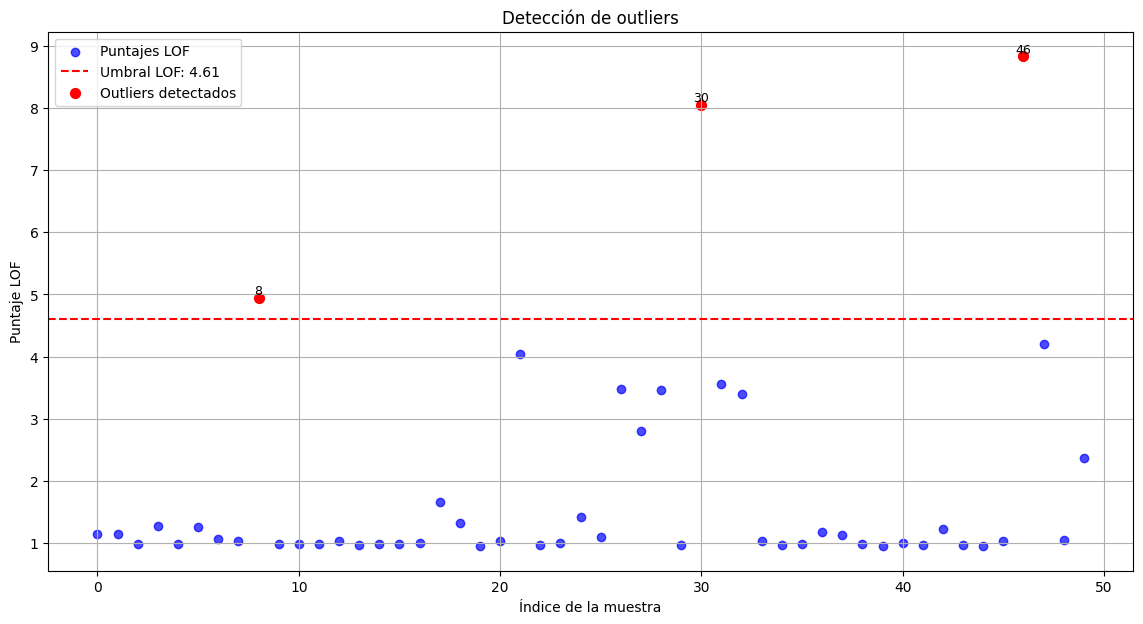

Cantidad de outliers detectados: 3

Datos extremos detectados (outliers):
    LOF_Score   mean_rr    std_rr   skew_rr    kurt_rr
8    4.947834  0.590612  0.108420  3.170219  13.347060
30   8.054009  0.912000  0.060578 -5.733077  38.214032
46   8.830793  0.669280  0.063024  5.681523  42.480822


In [61]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
X = df[columnas_numericas].values
y = df["label"].values

# Parámetros LOF
contamination = 0.05  
lof = LocalOutlierFactor(n_neighbors=10, contamination=contamination)

# Aplicar LOF
y_pred = lof.fit_predict(X)
scores = -lof.negative_outlier_factor_ 


df_outliers = df
# Agregar resultados al dataframe
df_outliers['LOF_Score'] = scores
df_outliers['Outlier'] = y_pred

# Calcular el umbral real basado en la contaminación
threshold = np.percentile(scores, 100 * (1 - contamination))

# Gráfico: puntajes LOF
plt.figure(figsize=(14, 7))
plt.scatter(range(len(scores)), scores, color='blue', alpha=0.7, label='Puntajes LOF')

# Dibujar la línea de umbral
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Umbral LOF: {threshold:.2f}')

# Resaltar los outliers en rojo
outlier_indices = np.where(scores > threshold)[0]
plt.scatter(outlier_indices, scores[outlier_indices], color='red', s=50, label='Outliers detectados')

# Etiquetar los outliers
for idx in outlier_indices:
    plt.text(idx, scores[idx], str(idx), fontsize=9, color='black', ha='center', va='bottom')

plt.title('Detección de outliers')
plt.xlabel('Índice de la muestra')
plt.ylabel('Puntaje LOF')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar resumen
print(f"Cantidad de outliers detectados: {len(df_outliers[df_outliers['Outlier'] == -1])}")
print("\nDatos extremos detectados (outliers):")
print(df_outliers[df_outliers['Outlier'] == -1][['LOF_Score'] + list(columnas_numericas)])

> Ahora veremos el "label" que tenía cada outlier


Distribución de clases dentro de los outliers detectados:
label
N    2
A    1
Name: count, dtype: int64


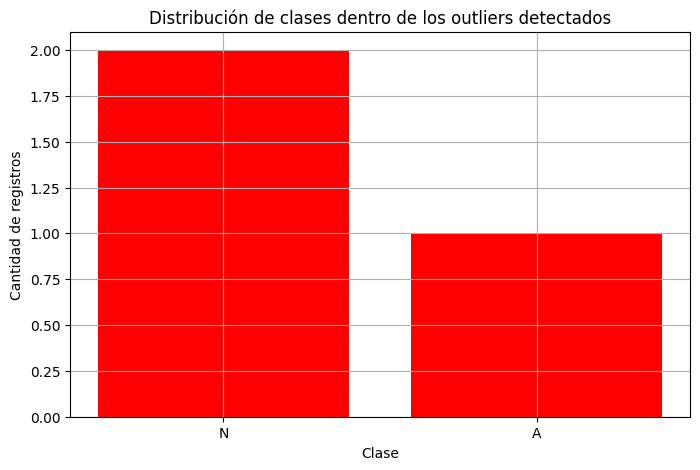

In [62]:
# Contar cuántos registros de cada clase hay dentro de los outliers
conteo_outliers_por_clase = df_outliers[df_outliers['Outlier'] == -1]['label'].value_counts()

print("\nDistribución de clases dentro de los outliers detectados:")
print(conteo_outliers_por_clase)

# Graficar la distribución de clases dentro de los outliers
plt.figure(figsize=(8, 5))
plt.bar(conteo_outliers_por_clase.index.astype(str), conteo_outliers_por_clase.values, color='red')
plt.title('Distribución de clases dentro de los outliers detectados')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')
plt.grid(True)
plt.show()

- Como podemos ver, hay 2 outliers que pertenecen a la clase "N" y 1 a la A. En este caso, eliminar estos outliers significa un desbalance de clases en el dataset. 
- Otro punto importante es evaluar si estos datos atípicos son fundamentales para el estudio, ya que quizás puedan haber electrocardiogramas con las mismas características, y entrenar el modelo sin estos datos podría ser perjudicial.
- Como solo estamos usando una muestra, es posible que estos datos no sean tan atípicos como se podría pensar en un principio, ya que esta muestra quizás no sea la mejor representación de los datos totales. 

### **2. Entrenamiento y Evaluación de mejor algoritmo a utilizar**

- En esta sección, se entrenarán distintos modelos supervisados de ML: Regresión lineal, Random Forest, Gradient Boosting, SVM, k-NN y MLP, capturando los resultados de cada uno de ellos mediante distintas métricas y evaluando cuál sería el modelo a utilizar según esas características.
- Se utilizará un entrenamiento con datos "train" (correspondientes al 80% del dataset) balanceados, así evitando que se genere un sesgo del modelo hacia la clase mayoritaria.
- Se escalarán los datos para aquellos modelos en que sea necesario hacerlo.

C:\Users\maxoO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


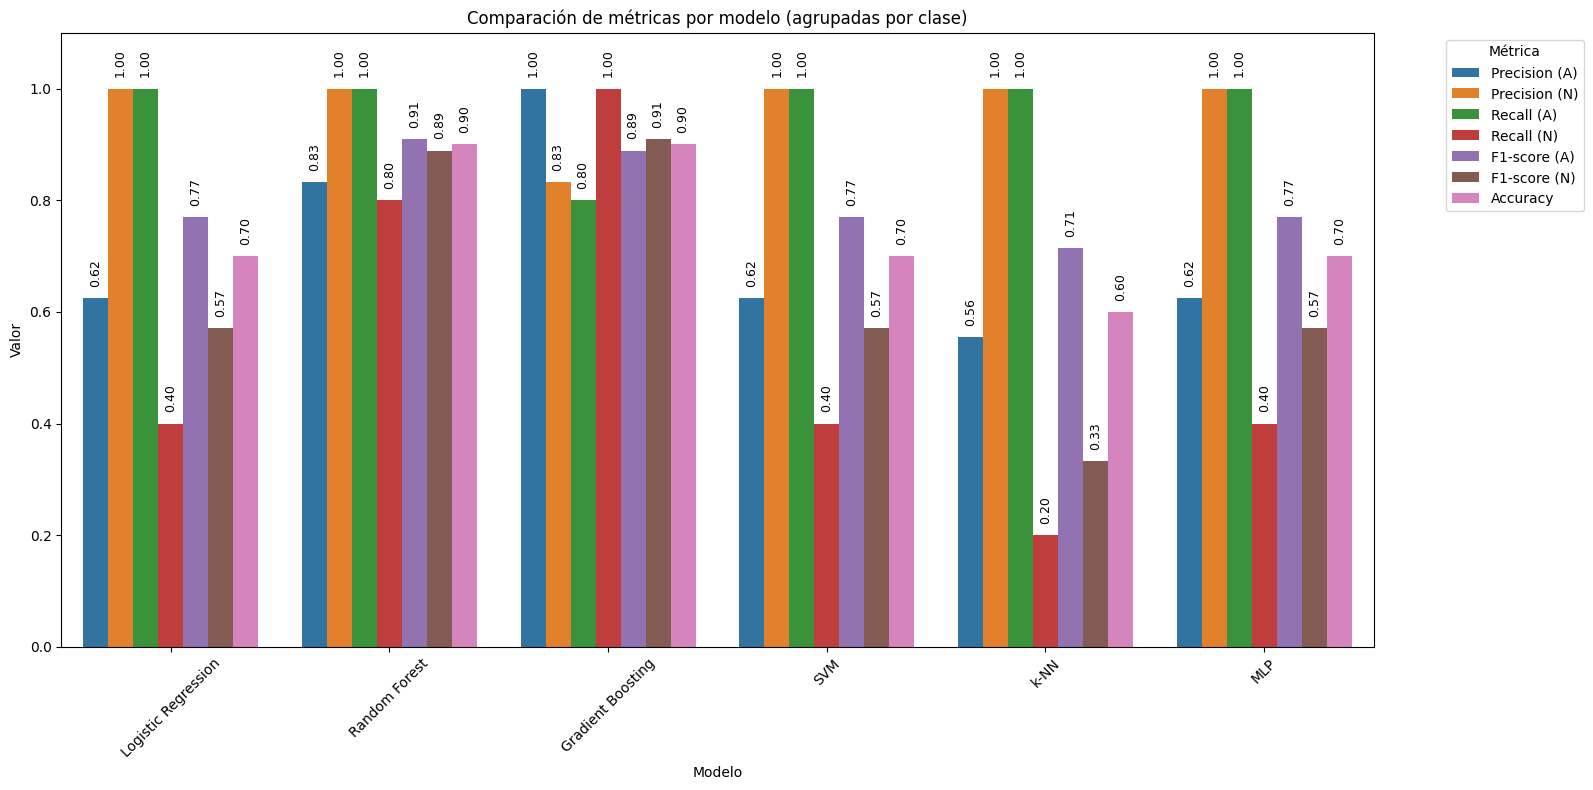

In [63]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(),
    'k-NN': KNeighborsClassifier(),
    'MLP': MLPClassifier(max_iter=500, random_state=42)
}

resultados = []

for name, model in models.items():
    # Escalado para modelos que lo necesitan
    if name in ['SVM', 'k-NN', 'MLP', 'Logistic Regression']:
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
    else:
        pipeline = Pipeline([('model', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    resultados.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Precision (A)': report.get('A', {}).get('precision', 0),
        'Recall (A)': report.get('A', {}).get('recall', 0),
        'F1-score (A)': report.get('A', {}).get('f1-score', 0),
        'Precision (N)': report.get('N', {}).get('precision', 0),
        'Recall (N)': report.get('N', {}).get('recall', 0),
        'F1-score (N)': report.get('N', {}).get('f1-score', 0),
    })

df_resultados = pd.DataFrame(resultados)

# Ordenamos las métricas
metricas = [
    'Precision (A)', 'Precision (N)',
    'Recall (A)', 'Recall (N)',
    'F1-score (A)', 'F1-score (N)',
    'Accuracy'
]

# Convertir a formato largo
df_long = df_resultados.melt(id_vars='Modelo', value_vars=metricas,
                             var_name='Métrica', value_name='Valor')

# Crear gráfico
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df_long, x='Modelo', y='Valor', hue='Métrica')

# Agregar etiquetas numéricas sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height + 0.02), 
                    ha='center', va='bottom', fontsize=9, rotation=90)

plt.title('Comparación de métricas por modelo (agrupadas por clase)')
plt.ylim(0, 1.1)
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Según estos resultados, podemos ver que Random Forest y Gradient Boosting tienen un desempeño mayor con este conjunto de datos, aunque podría presentarse un sobreajuste al dataset, ya que hay ciertas métricas que tienen un valor de 1 (100%), como por ejemplo la Precisión en la clase "N" de RF, lo que significa que todos los registros de esa clase fueron predecidos correctamente.